# Data Exploration and Analysis
## COM6033 - Applied Artificial Intelligence Project
### Market Trend Classification for North Yorkshire Property Market

**Dataset:** North Yorkshire Land Registry Price Paid Data (2019-2023)

---

## Project Overview

**Objective:** Build a machine learning system to classify property market trends across different areas in North Yorkshire.

**Classification Categories:**
- Booming (rapid price growth + high activity)
- Growing (steady price growth + moderate activity)
- Stable (minimal price changes + consistent activity)
- Declining (price decreases + falling activity)

**This Notebook:** Initial data exploration to understand the dataset structure, quality, and patterns before cleaning and modelling.

---

## Table of Contents
1. Data Loading
2. Basic Information
3. Property Type Distribution
4. Sample Data Inspection
5. Missing Data Analysis
6. Data Quality Checks
7. Temporal Analysis
8. Geographic Analysis
9. Price Distribution Analysis
10. Geographic & Property Type Cross-Analysis
11. Outlier Analysis
12. Key Findings & Next Steps

---



## 1. Data Loading

**What we're doing:** Loading the North Yorkshire property transaction data from the Land Registry Price Paid dataset.

**Why this matters:** The Land Registry provides comprehensive property sale data but doesn't include column headers by default. We need to manually assign meaningful column names to work with the data effectively.

**Data Source:** UK Land Registry Price Paid Data
**Filters Applied:**
- Geographic: North Yorkshire only
- Time Period: 2019-2024
- Data Type: All residential property transactions

**Expected Outcome:** A pandas Data Frame with ~60,000-70,000 transactions across 16 columns.

---



In [454]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Define Land Registry column names
column_names = [
    'transaction_id',
    'price',
    'date_transfer',
    'postcode',
    'property_type',
    'new_build',
    'duration',
    'paon',
    'saon',
    'street',
    'locality',
    'town_city',
    'district',
    'county',
    'ppd_category',
    'record_status'
]

# Load data
df = pd.read_csv(
    r'./data/raw/north_yorkshire_2019_2023.csv',
    header=None,
    names=column_names
)

print(f"\nData loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Data loaded successfully!
Rows: 67,232
Columns: 16


## 2. Basic Information

**What we're doing:** Examining the temporal and financial characteristics of the dataset.

**Why this matters:** Understanding the date range and price statistics helps us:
- Verify we have the expected time coverage
- Identify potential data quality issues
- Understand the market we're analysing
- Set appropriate expectations for our model

**Key Questions:**
- Do we have complete years of data?
- What's the typical price range?
- How many unique locations do we have?

---


In [455]:
# Convert date column to datetime
df['date_transfer'] = pd.to_datetime(df['date_transfer'])

print(f"\nDate Range:")
print(f"Earliest: {df['date_transfer'].min().strftime('%d %B %Y')}")
print(f"Latest:   {df['date_transfer'].max().strftime('%d %B %Y')}")
print(f"Span:     {(df['date_transfer'].max() - df['date_transfer'].min()).days} days")

print(f"\nPrice Statistics:")
print(f"Minimum:  £{df['price'].min():,.0f}")
print(f"Maximum:  £{df['price'].max():,.0f}")
print(f"Mean:     £{df['price'].mean():,.0f}")
print(f"Median:   £{df['price'].median():,.0f}")

print(f"\nGeographic Coverage:")
print(f"Unique postcodes: {df['postcode'].nunique():,}")
print(f"Unique towns:     {df['town_city'].nunique()}")
print(f"Districts:        {df['district'].nunique()}")


Date Range:
Earliest: 02 January 2019
Latest:   31 December 2023
Span:     1824 days

Price Statistics:
Minimum:  £100
Maximum:  £53,730,000
Mean:     £319,861
Median:   £245,000

Geographic Coverage:
Unique postcodes: 14,838
Unique towns:     40
Districts:        8


## 3. Property Type Distribution

**What we're doing:** Analysing the breakdown of property types in our dataset.

**Why this matters:**
- Different property types have different price behaviours
- Understanding the mix helps us know if our data is representative
- Some areas may be dominated by certain types (e.g., flats in cities)
- This affects how we should structure our market classification

**Property Type Codes:**
- D = Detached
- S = Semi-Detached
- T = Terraced
- F = Flat/Maisonette
- O = Other (commercial conversions, unique properties)

---


In [456]:
property_type_map = {
    'D': 'Detached',
    'S': 'Semi-Detached',
    'T': 'Terraced',
    'F': 'Flat/Maisonette',
    'O': 'Other'
}

df['property_type_desc'] = df['property_type'].map(property_type_map)

prop_counts = df['property_type_desc'].value_counts()
prop_percentages = df['property_type_desc'].value_counts(normalize=True) * 100

print("\nProperty Type:")
for ptype, count in prop_counts.items():
    pct = prop_percentages[ptype]
    print(f"{ptype:20s}: {count:6,} ({pct:5.1f}%)")


Property Type:
Detached            : 21,284 ( 31.7%)
Semi-Detached       : 17,890 ( 26.6%)
Terraced            : 15,987 ( 23.8%)
Flat/Maisonette     :  7,083 ( 10.5%)
Other               :  4,988 (  7.4%)


## 4. Sample Data Inspection

**What we're doing:** Examining the first few rows to understand data structure and quality.

**Why this matters:**
- Visual inspection helps identify data formatting issues
- We can see which fields commonly have missing values
- Helps us understand the level of detail available
- Validates our column naming is correct

**What to look for:**
- Are postcodes properly formatted?
- Do prices look reasonable?
- Are there obvious missing values?
- Do addresses look complete?

---

In [457]:
print(df.head())


                         transaction_id   price date_transfer  postcode  \
0  9DBAD222-17DD-6EB3-E053-6B04A8C0F257  850000    2019-12-12  BB18 6JR   
1  01EB45F0-9A06-40F3-E063-4704A8C05FDE  105000    2023-01-05  BD20 7AF   
2  DE2D0CE0-0B40-51EE-E053-6C04A8C00671  210000    2022-03-17  BD20 7AJ   
3  E7B085FD-432F-7E31-E053-6C04A8C0E67F  209950    2022-04-01  BD20 7AJ   
4  93E6821E-AE5F-40FD-E053-6B04A8C0C1DF  195000    2019-08-19  BD20 7AJ   

  property_type new_build duration         paon               saon  \
0             S         N        F          NaN          THE MOUNT   
1             O         N        L            4     SPINNINGFIELDS   
2             F         N        L  APARTMENT 3  SUTTON GATE LODGE   
3             F         N        L  APARTMENT 4  SUTTON GATE LODGE   
4             F         N        L  APARTMENT 8  SUTTON GATE LODGE   

           street          locality     town_city         district  \
0   GAYLANDS LANE             EARBY  BARNOLDSWICK         

## 5. Missing Data Analysis

**What we're doing:** Identifying which columns have missing values and how much data is missing.

**Why this matters:**
- Missing data can bias our model
- Some missing fields are critical (price, date) while others aren't (flat number)
- We need to decide: delete rows, impute values, or keep as-is

**Critical vs Non-Critical Fields:**
- **Critical:** price, date, postcode (needed for analysis)
- **Non-Critical:** PAON, SAON, locality (address details, not needed for trend classification)

**Decision Framework:**
- <1% missing: Can safely remove rows
- 1-10% missing: Evaluate if field is critical
- >10% missing: Consider if field is needed at all

---


Columns with Missing Data:
  Column  Missing_Count  Missing_Percentage
    paon          60477           89.952701
locality          32107           47.755533
  street           4593            6.831568
postcode            214            0.318301


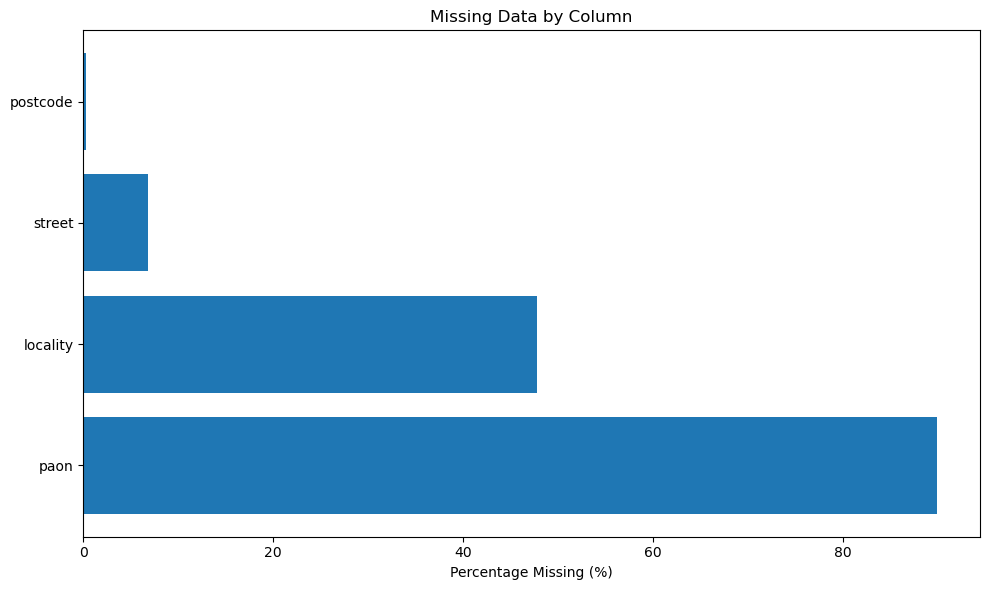


Overall Data Completeness: 91.48%


In [458]:
# Calculate missing values
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Create missing data summary
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_counts.values,
    'Missing_Percentage': missing_percentages.values
})

# Sort by missing percentage
missing_summary = missing_summary.sort_values('Missing_Percentage', ascending=False)
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

print("\nColumns with Missing Data:")
print(missing_summary.to_string(index=False))

# Visualise missing data
plt.figure(figsize=(10, 6))
missing_summary_plot = missing_summary[missing_summary['Missing_Percentage'] > 0]
plt.barh(missing_summary_plot['Column'], missing_summary_plot['Missing_Percentage'])
plt.xlabel('Percentage Missing (%)')
plt.title('Missing Data by Column')
plt.tight_layout()
plt.show()

# Overall completeness
total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()
completeness = ((total_cells - missing_cells) / total_cells) * 100

print(f"\nOverall Data Completeness: {completeness:.2f}%")

## 6. Data Quality Checks

**What we're doing:** Identifying outliers, anomalies, and potential data errors.

**Why this matters:**
- Outliers can severely skew ML model training
- Extreme values might be data errors rather than real transactions
- Understanding price ranges helps set realistic model expectations
- Different property types have different normal ranges

**Types of Issues to Check:**
1. **Price outliers:** Extremely low (< £30k) or high (> £2M) prices
2. **Date errors:** Future dates or dates outside expected range
3. **Postcode validity:** Correctly formatted postcodes
4. **Geographic consistency:** All records should be North Yorkshire

**Approach:** Use statistical methods (IQR, percentiles) combined with domain knowledge of the UK property market.

---

In [459]:
# 1. Price Outliers

# Price statistics
price_stats = df['price'].describe()
print(f"\nPrice Statistics:")
print(f"Count:  {price_stats['count']:,.0f}")
print(f"Mean:   £{price_stats['mean']:,.0f}")
print(f"Std:    £{price_stats['std']:,.0f}")
print(f"Min:    £{price_stats['min']:,.0f}")
print(f"25%:    £{price_stats['25%']:,.0f}")
print(f"Median: £{price_stats['50%']:,.0f}")
print(f"75%:    £{price_stats['75%']:,.0f}")
print(f"Max:    £{price_stats['max']:,.0f}")

# Identify extreme outliers
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 3 * iqr  # Using 3*IQR for extreme outliers
upper_bound = q3 + 3 * iqr

extreme_low = df[df['price'] < lower_bound]
extreme_high = df[df['price'] > upper_bound]

print(f"\nExtreme Price Outliers:")
print(f"Very low (< £{lower_bound:,.0f}): {len(extreme_low):,} transactions ({len(extreme_low)/len(df)*100:.2f}%)")
print(f"Very high (> £{upper_bound:,.0f}): {len(extreme_high):,} transactions ({len(extreme_high)/len(df)*100:.2f}%)")

# Show some extreme examples
if len(extreme_high) > 0:
    print(f"\nTop 5 Most Expensive Properties:")
    expensive = df.nlargest(5,'price')[['price', 'property_type_desc', 'town_city', 'date_transfer']]
    print(expensive.to_string())

if len(extreme_low) > 0:
    print(f"\nBottom 5 Cheapest Properties:")
    cheap = df.nsmallest(5,'price')[['price', 'property_type_desc', 'town_city', 'date_transfer']]
    print(cheap.to_string())


Price Statistics:
Count:  67,232
Mean:   £319,861
Std:    £508,020
Min:    £100
25%:    £174,000
Median: £245,000
75%:    £363,999
Max:    £53,730,000

Extreme Price Outliers:
Very low (< £-395,998): 0 transactions (0.00%)
Very high (> £933,997): 1,549 transactions (2.30%)

Top 5 Most Expensive Properties:
          price property_type_desc      town_city date_transfer
55042  53730000              Other           YORK    2023-04-24
55043  53100000              Other           YORK    2021-09-30
3061   30750000              Other        SKIPTON    2023-06-26
29779  30000000              Other  KNARESBOROUGH    2019-08-01
19222  20000000              Other      HARROGATE    2020-12-15


In [460]:
# 2. Date Quality

# Check for any future dates or very old dates
today = pd.Timestamp.now()
future_dates = df[df['date_transfer'] > today]
very_old_dates = df[df['date_transfer'] < '2019-01-01']

print(f"Future dates: {len(future_dates)}")
print(f"Dates before 2019: {len(very_old_dates)}")

Future dates: 0
Dates before 2019: 0


In [461]:
# 3. Postcode Quality

# Check for invalid postcodes
invalid_postcodes = df[df['postcode'].str.len() < 5]['postcode'].count()

# Show postcode distribution
postcode_sectors = df['postcode'].str.split().str[0]  # Get first part (e.g., 'BD20')
top_sectors = postcode_sectors.value_counts().head(10)
print(f"\nTop 10 Postcode Sectors:")
for sector, count in top_sectors.items():
    print(f"{sector}: {count:,} transactions")


Top 10 Postcode Sectors:
YO8: 5,037 transactions
HG1: 4,289 transactions
YO12: 4,048 transactions
YO11: 3,453 transactions
HG3: 3,410 transactions
HG2: 3,321 transactions
BD23: 3,263 transactions
HG4: 2,648 transactions
YO7: 2,516 transactions
YO17: 2,187 transactions


In [462]:
# 4. County Verification

county_counts = df['county'].value_counts()
print(f"Unique counties: {df['county'].nunique()}")
for county, count in county_counts.items():
    print(f"{county}: {count:,} ({count/len(df)*100:.1f}%)")

Unique counties: 1
NORTH YORKSHIRE: 67,232 (100.0%)


## 7. Temporal Analysis

**What we're doing:** Analysing how property transactions and prices change over time.

**Why this matters:**
- Time is a key feature for market trend classification
- Understanding temporal patterns helps us create meaningful features
- COVID-19 significantly impacted the property market (2020-2021)
- Seasonal patterns affect transaction volumes

**What we're looking for:**
- Year-over-year transaction volume changes
- Price trends over time
- Seasonal patterns (spring typically busier than winter)
- Impact of major events (COVID lockdowns, stamp duty holiday)

**This analysis will inform:**
- How we aggregate data (monthly? quarterly?)
- Whether to include seasonal features
- How to handle the COVID period in our model

---

In [463]:
# Extract temporal features
df['year'] = df['date_transfer'].dt.year
df['month'] = df['date_transfer'].dt.month
df['quarter'] = df['date_transfer'].dt.quarter
df['year_month'] = df['date_transfer'].dt.to_period('M')

# Transactions by year
print("\nTransactions by Year:")
yearly_counts = df['year'].value_counts().sort_index()
for year, count in yearly_counts.items():
    print(f"  {year}: {count:6,} transactions")

# Average price by year
print("\nAverage Price by Year:")
yearly_avg_price = df.groupby('year')['price'].mean()
for year, price in yearly_avg_price.items():
    print(f"  {year}: £{price:,.0f}")


Transactions by Year:
  2019: 13,309 transactions
  2020: 11,960 transactions
  2021: 16,826 transactions
  2022: 13,704 transactions
  2023: 11,433 transactions

Average Price by Year:
  2019: £286,088
  2020: £297,021
  2021: £326,480
  2022: £342,634
  2023: £346,030


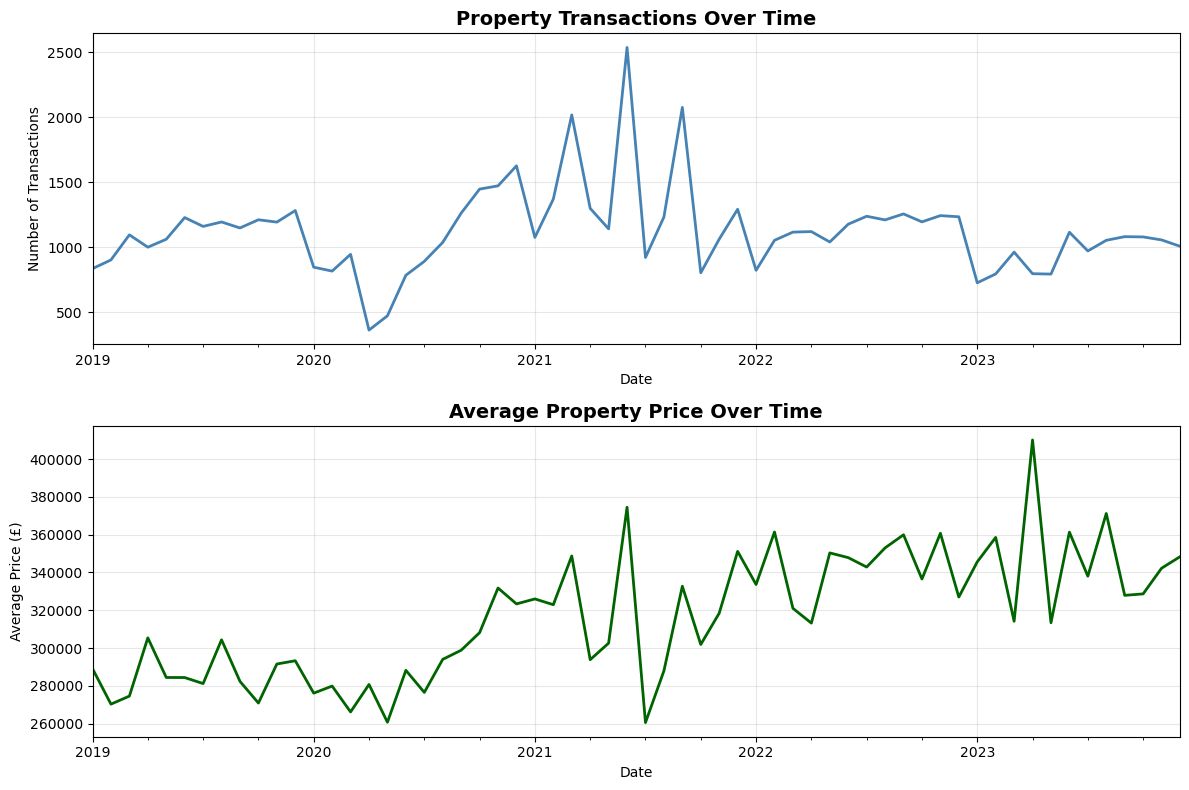

In [464]:
# Visualize transactions over time
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Transactions per month
monthly_counts = df.groupby('year_month').size()
monthly_counts.plot(ax=axes[0], linewidth=2, color='steelblue')
axes[0].set_title('Property Transactions Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Number of Transactions')
axes[0].grid(True, alpha=0.3)

# Plot 2: Average price over time
monthly_avg_price = df.groupby('year_month')['price'].mean()
monthly_avg_price.plot(ax=axes[1], linewidth=2, color='darkgreen')
axes[1].set_title('Average Property Price Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Price (£)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [465]:
# Seasonal patterns
seasonal_counts = df.groupby('month').size()
seasonal_avg = df.groupby('month')['price'].mean()

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
print("\nAverage by Month:")
for month_num in range(1, 13):
    if month_num in seasonal_counts.index:
        count = seasonal_counts[month_num]
        avg_price = seasonal_avg[month_num]
        print(f"  {months[month_num-1]}: {count:5,} transactions, Avg: £{avg_price:,.0f}")


Average by Month:
  Jan: 4,304 transactions, Avg: £313,784
  Feb: 4,935 transactions, Avg: £320,133
  Mar: 6,136 transactions, Avg: £312,312
  Apr: 4,577 transactions, Avg: £320,283
  May: 4,507 transactions, Avg: £306,841
  Jun: 6,841 transactions, Avg: £341,718
  Jul: 5,181 transactions, Avg: £302,097
  Aug: 5,726 transactions, Avg: £321,516
  Sep: 6,823 transactions, Avg: £322,218
  Oct: 5,735 transactions, Avg: £309,164
  Nov: 6,026 transactions, Avg: £329,264
  Dec: 6,441 transactions, Avg: £327,546


In [466]:
# Year-over-year analysis
print("\nTransaction Volume Changes:")
for i, year in enumerate(yearly_counts.index[1:], 1):
    prev_year = yearly_counts.index[i-1]
    current_count = yearly_counts[year]
    prev_count = yearly_counts[prev_year]
    change = ((current_count - prev_count) / prev_count) * 100

    print(f"{prev_year} → {year}: {prev_count:,} → {current_count:,} ({change:+.1f}%)")

print("\nAverage Price Changes:")
for i, year in enumerate(yearly_avg_price.index[1:], 1):
    prev_year = yearly_avg_price.index[i-1]
    current_price = yearly_avg_price[year]
    prev_price = yearly_avg_price[prev_year]
    change = ((current_price - prev_price) / prev_price) * 100

    print(f"{prev_year} → {year}: £{prev_price:,.0f} → £{current_price:,.0f} ({change:+.1f}%)")


Transaction Volume Changes:
2019 → 2020: 13,309 → 11,960 (-10.1%)
2020 → 2021: 11,960 → 16,826 (+40.7%)
2021 → 2022: 16,826 → 13,704 (-18.6%)
2022 → 2023: 13,704 → 11,433 (-16.6%)

Average Price Changes:
2019 → 2020: £286,088 → £297,021 (+3.8%)
2020 → 2021: £297,021 → £326,480 (+9.9%)
2021 → 2022: £326,480 → £342,634 (+4.9%)
2022 → 2023: £342,634 → £346,030 (+1.0%)


## 8. Geographic Analysis

**What we're doing:** Understanding property patterns across different locations in North Yorkshire.

**Why this matters:**
- Location is the main factor we'll use for market classification
- Different areas have different market characteristics
- We need to identify the right geographic postcode sector to use for classification
- Urban vs rural areas may behave very differently

**Geographic Hierarchy:**
- County: North Yorkshire (our filter)
- District: 8 districts (e.g., Harrogate, Craven)
- Town: ~40 towns (e.g., Harrogate town, Skipton)
- Postcode Sector: ~200+ sectors (e.g., HG1, BD20)

**Classification Target:** We'll classify at the **postcode sector** level - specific enough to show local variation but broad enough to have sufficient data.

**Questions:**
- Which areas have the most activity?
- Are there price differences between districts?
- Do we have enough data per postcode sector?

---

In [467]:
# District analysis
district_stats = df.groupby('district').agg({
    'price': ['count', 'mean', 'median']
}).round(0)

district_stats.columns = ['Transactions', 'Avg_Price', 'Median_Price']
district_stats = district_stats.sort_values('Transactions', ascending=False)

print("\nDistrict Statistics:")
print(district_stats)


District Statistics:
                 Transactions  Avg_Price  Median_Price
district                                              
NORTH YORKSHIRE         15540   353761.0      265000.0
HARROGATE               13891   404221.0      308000.0
SCARBOROUGH             10420   214637.0      177500.0
SELBY                    7625   259606.0      220000.0
HAMBLETON                7085   318994.0      250000.0
CRAVEN                   5004   300696.0      238000.0
RYEDALE                  4392   329425.0      250000.0
RICHMONDSHIRE            3275   294597.0      230000.0


## 9. Price Distribution Analysis

**What we're doing:** Visualizing how property prices are distributed across our dataset.

**Why this matters:**
- Understanding distribution shapes helps us choose appropriate ML algorithms
- Identifies where most properties cluster (typical market)
- Shows how extreme our outliers are
- Different property types have different price distributions
- Helps justify our outlier removal thresholds

**Statistical Concepts:**
- **Normal distribution:** Prices should roughly follow a bell curve (with right skew)
- **Right skew:** More expensive properties pull the mean higher than median
- **Outliers:** Values far from the typical range
- **Multimodal:** Different property types create multiple peaks

**Analysis Approaches:**
1. Overall distribution (all properties)
2. Zoomed distribution (excluding extremes for clarity)
3. By property type (detached vs flats behave differently)
4. Log scale (helps visualize extreme values)

---

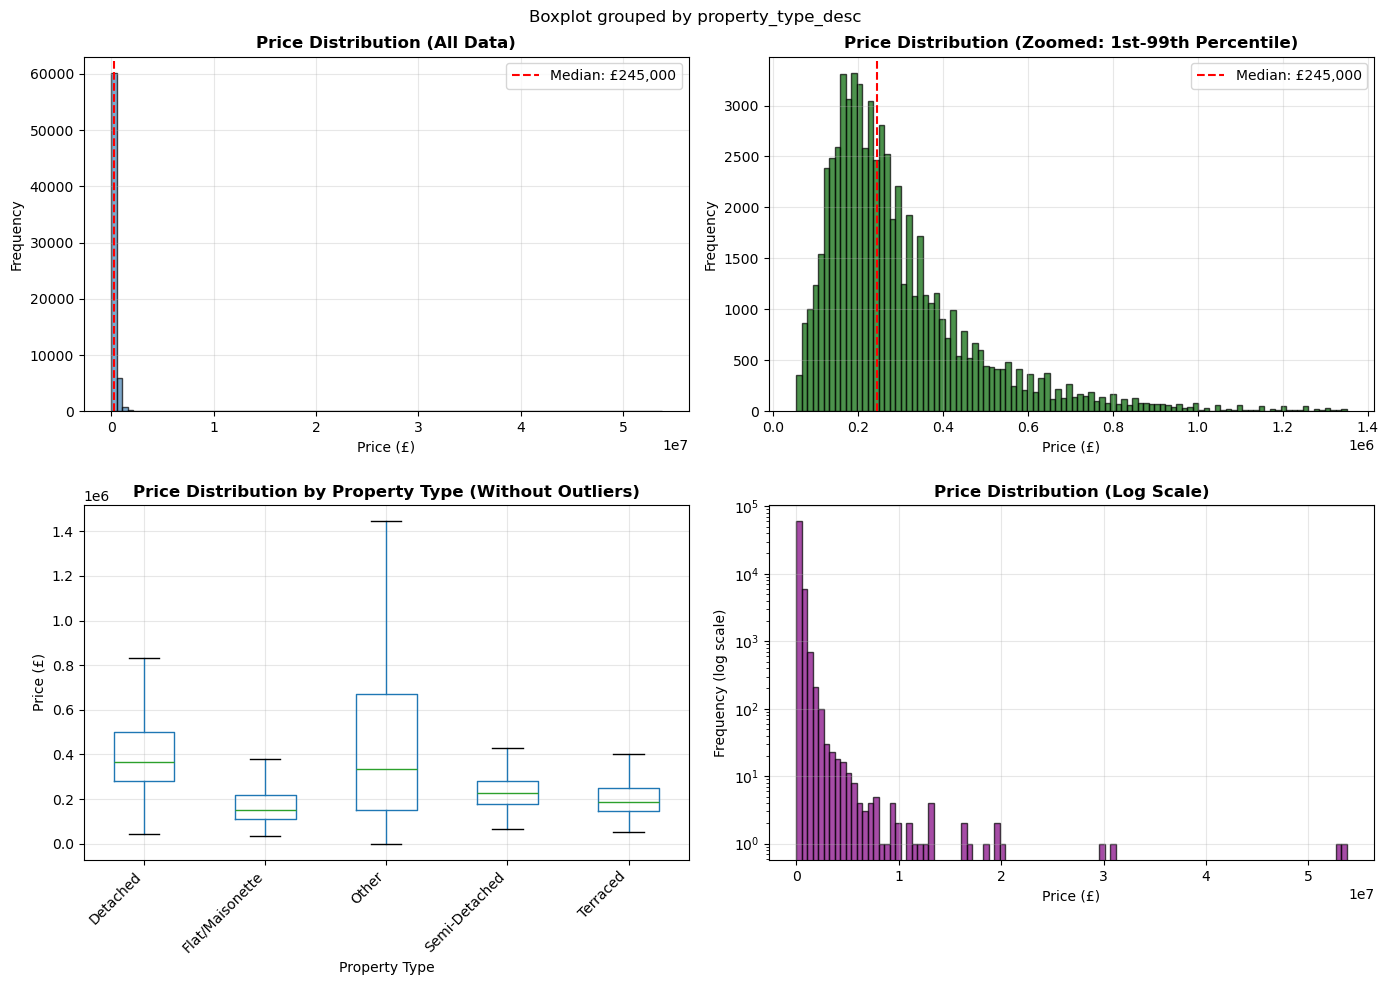


Price Statistics by Property Type:
                      count      mean        std      min       25%       50%  \
property_type_desc                                                              
Detached            21284.0  426126.0   237485.0  43000.0  280000.0  365000.0   
Flat/Maisonette      7083.0  181946.0   119748.0  36000.0  110000.0  151000.0   
Other                4988.0  652249.0  1696261.0    100.0  152375.0  335000.0   
Semi-Detached       17890.0  249897.0   126182.0  67000.0  179995.0  225000.0   
Terraced            15987.0  214075.0   118051.0  51500.0  145000.0  185000.0   

                         75%         max  
property_type_desc                        
Detached            500000.0   5250000.0  
Flat/Maisonette     218376.0   2500000.0  
Other               670000.0  53730000.0  
Semi-Detached       280000.0   2250000.0  
Terraced            248000.0   1885000.0  


In [468]:
# Create price distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Overall price distribution (with outliers)
axes[0, 0].hist(df['price'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Price Distribution (All Data)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Price (£)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['price'].median(), color='red', linestyle='--', label=f'Median: £{df["price"].median():,.0f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Price distribution (zoomed in, excluding extremes)
# Remove top and bottom 1% for better visualization
price_99 = df['price'].quantile(0.99)
price_01 = df['price'].quantile(0.01)
df_zoomed = df[(df['price'] >= price_01) & (df['price'] <= price_99)]

axes[0, 1].hist(df_zoomed['price'], bins=100, color='darkgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Price Distribution (Zoomed: 1st-99th Percentile)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Price (£)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df_zoomed['price'].median(), color='red', linestyle='--', label=f'Median: £{df_zoomed["price"].median():,.0f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Box plot by property type
df.boxplot(column='price', by='property_type_desc', ax=axes[1, 0],
           showfliers=False)  # Hide outliers for clarity
axes[1, 0].set_title('Price Distribution by Property Type (Without Outliers)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Property Type')
axes[1, 0].set_ylabel('Price (£)')
axes[1, 0].grid(True, alpha=0.3)
plt.sca(axes[1, 0])
plt.xticks(rotation=45, ha='right')

# Plot 4: Log scale price distribution
axes[1, 1].hist(df['price'], bins=100, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Price Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Price (£)')
axes[1, 1].set_ylabel('Frequency (log scale)')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate price statistics by property type
print("\nPrice Statistics by Property Type:")
print("="*60)
price_by_type = df.groupby('property_type_desc')['price'].describe()
print(price_by_type.round(0))

## 10. Geographic & Property Type Cross-Analysis

**What we're doing:** Examining how property types vary across different locations.

**Why this matters:**
- Market trends may differ by property type AND location
- Urban areas: More flats, lower prices
- Rural areas: More detached, higher prices
- Understanding these patterns helps us build a nuanced classification

**Real-World Examples:**
- Harrogate town center: High proportion of flats, mixed prices
- Rural Craven: Dominated by detached houses, higher average prices
- Market towns: Mix of terraced and semi-detached, moderate prices

**Implications for Model:**
- Should we classify different property types separately?
- Do some areas have unique characteristics?
- Are there areas with insufficient data for reliable classification?

**This analysis informs:**
- Feature engineering decisions
- Whether to segment our model by property type
- How to handle areas with unusual compositions

---


Property Type Percentage by District:
property_type_desc  Detached  Flat/Maisonette  Other  Semi-Detached  Terraced
district                                                                     
CRAVEN                  21.8              8.9    7.7           22.6      39.1
HAMBLETON               40.1              5.1    8.0           26.3      20.5
HARROGATE               32.1             13.0    6.1           26.2      22.5
NORTH YORKSHIRE         32.8             10.8    9.2           26.9      20.2
RICHMONDSHIRE           31.4              3.5   10.5           27.8      26.9
RYEDALE                 37.2              4.2    8.5           25.9      24.2
SCARBOROUGH             19.2             21.2    7.2           26.3      26.1
SELBY                   41.1              3.7    3.7           29.9      21.5


<Figure size 1200x600 with 0 Axes>

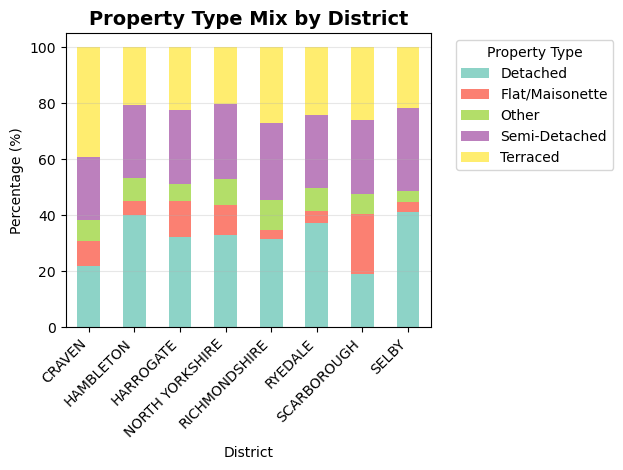


2. TOP 10 TOWNS - PROPERTY TYPE MIX:
------------------------------------------------------------
property_type_desc  Detached  Flat/Maisonette  Other  Semi-Detached  Terraced
town_city                                                                    
HARROGATE               2932             1926    615           3016      2550
MALTON                   762               98    183            642       506
NORTHALLERTON           1099              145    217            824       670
RIPON                    817              341    227            645       628
SCARBOROUGH             1584             1817    549           2473      2140
SELBY                   1918              229    185           1543      1172
SKIPTON                  712              330    237            783      1210
THIRSK                   996              142    213            692       483
WHITBY                   654              573    291            594       776
YORK                    2950              1

In [469]:
district_property_type = pd.crosstab(
    df['district'],
    df['property_type_desc'],
    normalize='index'
) * 100

print("\nProperty Type Percentage by District:")
print(district_property_type.round(1))

# Visualize
plt.figure(figsize=(12, 6))
district_property_type.plot(kind='bar', stacked=True, colormap='Set3')
plt.title('Property Type Mix by District', fontsize=14, fontweight='bold')
plt.xlabel('District')
plt.ylabel('Percentage (%)')
plt.legend(title='Property Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Top towns with their property type mix
print("\n2. TOP 10 TOWNS - PROPERTY TYPE MIX:")
print("-" * 60)

top_towns = df['town_city'].value_counts().head(10).index
town_property_mix = df[df['town_city'].isin(top_towns)].groupby(
    ['town_city', 'property_type_desc']
).size().unstack(fill_value=0)

print(town_property_mix)

# Identify areas with unique characteristics
print("\n3. MARKET CHARACTERISTICS BY AREA:")
print("-" * 60)

district_stats = df.groupby('district').agg({
    'price': ['mean', 'median', 'count'],
    'property_type_desc': lambda x: x.value_counts().index[0]  # Most common type
})

district_stats.columns = ['Avg_Price', 'Median_Price', 'Transactions', 'Most_Common_Type']
district_stats = district_stats.sort_values('Avg_Price', ascending=False)

print("\nDistrict Profiles:")
for district, row in district_stats.iterrows():
    print(f"\n{district}:")
    print(f"  Avg Price: £{row['Avg_Price']:,.0f}")
    print(f"  Median Price: £{row['Median_Price']:,.0f}")
    print(f"  Transactions: {row['Transactions']:,}")
    print(f"  Dominant Property Type: {row['Most_Common_Type']}")

## 11. Outlier Analysis & Cleaning Thresholds

**What we're doing:** Using statistical methods to identify outliers and determine appropriate removal thresholds.

**Why this matters:**
- Outliers can severely distort ML model training
- But not all outliers are errors - some are legitimate luxury properties
- We need evidence-based, justified thresholds
- Must balance data quality with sample size

**Statistical Method: Interquartile Range (IQR)**
- Q1 (25th percentile): 25% of prices are below this
- Q3 (75th percentile): 75% of prices are below this
- IQR = Q3 - Q1 (the "middle 50%" range)
- Outliers: < Q1 - 1.5×IQR or > Q3 + 1.5×IQR
- Extreme outliers: < Q1 - 3×IQR or > Q3 + 3×IQR

**Domain Knowledge Application:**
- Properties < £30k: Likely non-market sales (family transfers, part-exchanges, garages)
- Properties > £2M: Likely estates, commercial, or luxury (not representative)
- North Yorkshire typical range: £50k - £800k

**Ethical Consideration:**
- Removing outliers could bias against luxury/budget segments
- BUT: Our model is for typical residential market trends
- We'll document what we remove and why

**Goal:** Remove < 1% of data as outliers while improving model quality.

---

In [470]:
# Use IQR method to identify outliers
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1

# Calculate different outlier thresholds
lower_iqr = q1 - 1.5 * iqr
upper_iqr = q3 + 1.5 * iqr
lower_extreme = q1 - 3 * iqr
upper_extreme = q3 + 3 * iqr

print("\nOutlier Thresholds (IQR Method):")
print(f"Q1 (25th percentile): £{q1:,.0f}")
print(f"Q3 (75th percentile): £{q3:,.0f}")
print(f"IQR: £{iqr:,.0f}")
print(f"\nMild outliers:    < £{lower_iqr:,.0f} or > £{upper_iqr:,.0f}")
print(f"Extreme outliers: < £{lower_extreme:,.0f} or > £{upper_extreme:,.0f}")

# Count outliers at different thresholds
mild_low = df[df['price'] < lower_iqr]
mild_high = df[df['price'] > upper_iqr]
extreme_low = df[df['price'] < lower_extreme]
extreme_high = df[df['price'] > upper_extreme]

print(f"\nOutlier Counts:")
print(f"Mild low:     {len(mild_low):,} ({len(mild_low)/len(df)*100:.2f}%)")
print(f"Mild high:    {len(mild_high):,} ({len(mild_high)/len(df)*100:.2f}%)")
print(f"Extreme low:  {len(extreme_low):,} ({len(extreme_low)/len(df)*100:.2f}%)")
print(f"Extreme high: {len(extreme_high):,} ({len(extreme_high)/len(df)*100:.2f}%)")

# Analyze extreme outliers in detail
print("\nEXTREME PRICE OUTLIERS")
print("="*60)

if len(extreme_high) > 0:
    print(f"\nTop 10 Most Expensive Properties:")
    expensive = df.nlargest(10, 'price')[
        ['price', 'property_type_desc', 'town_city', 'district', 'date_transfer', 'new_build']
    ]
    print(expensive.to_string(index=False))

if len(extreme_low) > 0:
    print(f"\nBottom 10 Cheapest Properties:")
    cheap = df.nsmallest(10, 'price')[
        ['price', 'property_type_desc', 'town_city', 'district', 'date_transfer', 'new_build']
    ]
    print(cheap.to_string(index=False))

# Proposed cleaning thresholds
print("\nPROPOSED CLEANING THRESHOLDS")
print("="*60)

# Reasonable thresholds based on North Yorkshire market
min_threshold = 30000  # Below this likely errors or non-standard sales
max_threshold = 2000000  # Above this likely estates/commercial

below_min = df[df['price'] < min_threshold]
above_max = df[df['price'] > max_threshold]

print(f"\nProposed Thresholds:")
print(f"Minimum: £{min_threshold:,}")
print(f"Maximum: £{max_threshold:,}")
print(f"\nWould Remove:")
print(f"Below minimum: {len(below_min):,} ({len(below_min)/len(df)*100:.2f}%)")
print(f"Above maximum: {len(above_max):,} ({len(above_max)/len(df)*100:.2f}%)")
print(f"Total removed: {len(below_min) + len(above_max):,} ({(len(below_min) + len(above_max))/len(df)*100:.2f}%)")
print(f"Remaining:     {len(df) - len(below_min) - len(above_max):,} ({(len(df) - len(below_min) - len(above_max))/len(df)*100:.2f}%)")

print(f"\nRemoving < 1% of data as outliers is acceptable for ML model quality")


Outlier Thresholds (IQR Method):
Q1 (25th percentile): £174,000
Q3 (75th percentile): £363,999
IQR: £189,999

Mild outliers:    < £-110,999 or > £648,998
Extreme outliers: < £-395,998 or > £933,997

Outlier Counts:
Mild low:     0 (0.00%)
Mild high:    4,455 (6.63%)
Extreme low:  0 (0.00%)
Extreme high: 1,549 (2.30%)

EXTREME PRICE OUTLIERS

Top 10 Most Expensive Properties:
   price property_type_desc          town_city        district date_transfer new_build
53730000              Other               YORK NORTH YORKSHIRE    2023-04-24         N
53100000              Other               YORK         RYEDALE    2021-09-30         N
30750000              Other            SKIPTON NORTH YORKSHIRE    2023-06-26         N
30000000              Other      KNARESBOROUGH       HARROGATE    2019-08-01         N
20000000              Other          HARROGATE       HARROGATE    2020-12-15         N
19691222              Other          HARROGATE NORTH YORKSHIRE    2022-09-05         N
19500000    

## 12. Key Findings & Next Steps

**What we're doing:** Summarizing our exploration findings and documenting decisions for the next phase.

**Why this matters:**
- Clear documentation of our thought process
- Justifies our data cleaning approach
- Shows critical thinking and analysis
- Creates a roadmap for the next notebook

---

In [471]:
# Make sure we have postcode_sector
if 'postcode_sector' not in df.columns:
    df['postcode_sector'] = df['postcode'].str.split().str[0]

print("\nDATASET SUMMARY:")
print(f"Total Transactions: {len(df):,}")
print(f"Time Period: Jan 2019 - Dec 2023 (5 complete years)")
print(f"Geographic Coverage: {df['district'].nunique()} districts, {df['town_city'].nunique()} towns")
print(f"Postcode Sectors: {df['postcode_sector'].nunique()}")
print(f"Property Types: 5 categories")

print("\nDATA QUALITY:")
completeness = ((df.shape[0] * df.shape[1] - df.isnull().sum().sum()) / (df.shape[0] * df.shape[1])) * 100
print(f"Overall Completeness: {completeness:.1f}%")
print(f"Critical fields (price, date, postcode): 100% complete")
print(f"Missing data in non-critical address fields only")

print("\nMARKET INSIGHTS:")
print(f"Price Range: £{df['price'].min():,.0f} - £{df['price'].max():,.0f}")
print(f"Median Price: £{df['price'].median():,.0f}")
print(f"Market includes COVID crash (2020) and recovery (2021-2023)")
print(f"Diverse property mix: Detached (31.7%) to Flats (10.5%)")


DATASET SUMMARY:
Total Transactions: 67,232
Time Period: Jan 2019 - Dec 2023 (5 complete years)
Geographic Coverage: 8 districts, 40 towns
Postcode Sectors: 63
Property Types: 5 categories

DATA QUALITY:
Overall Completeness: 93.4%
Critical fields (price, date, postcode): 100% complete
Missing data in non-critical address fields only

MARKET INSIGHTS:
Price Range: £100 - £53,730,000
Median Price: £245,000
Market includes COVID crash (2020) and recovery (2021-2023)
Diverse property mix: Detached (31.7%) to Flats (10.5%)


In [472]:
# Calculate outliers for summary
min_threshold = 30000
max_threshold = 2000000
below_min = df[df['price'] < min_threshold]
above_max = df[df['price'] > max_threshold]

print("\nISSUES IDENTIFIED:")
print(f"Extreme outliers: {len(above_max) + len(below_min):,} properties outside normal range")
print(f"Some very low prices (< £30k) - likely non-market sales")
print(f"Some very high prices (> £2M) - likely estates/commercial")
print(f"Missing address details in some records (acceptable)")

print("\nDECISIONS FOR DATA CLEANING PHASE:")
print("Remove price outliers: Keep only £30,000 - £2,000,000")
print("Retain missing non-critical fields (PAON, locality, SAON)")
print("Focus on postcode sectors with 20+ transactions")
print("Create temporal features (year, quarter, month)")
print("Extract postcode sectors for aggregation")

print("\nNEXT NOTEBOOK: 02_data_cleaning.ipynb")
print("Tasks:")
print("Apply outlier removal thresholds")
print("Handle missing values")
print("Filter low-volume postcode sectors")
print("Create derived features")
print("Save cleaned dataset")



ISSUES IDENTIFIED:
Extreme outliers: 648 properties outside normal range
Some very low prices (< £30k) - likely non-market sales
Some very high prices (> £2M) - likely estates/commercial
Missing address details in some records (acceptable)

DECISIONS FOR DATA CLEANING PHASE:
Remove price outliers: Keep only £30,000 - £2,000,000
Retain missing non-critical fields (PAON, locality, SAON)
Focus on postcode sectors with 20+ transactions
Create temporal features (year, quarter, month)
Extract postcode sectors for aggregation

NEXT NOTEBOOK: 02_data_cleaning.ipynb
Tasks:
Apply outlier removal thresholds
Handle missing values
Filter low-volume postcode sectors
Create derived features
Save cleaned dataset
